# Cardiac EDA
Exploratory analysis of the cardiac datasets with pipeline-aligned data stages and consistent comparisons.

## Imports
Load required libraries for data handling, plotting, and lightweight statistics.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import json
import warnings
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## Paths and configuration
Define project paths, load pipeline config, and set shared color mappings.

In [2]:
ROOT_DIR = Path.cwd().resolve()
if (ROOT_DIR / "configs").exists() is False:
    ROOT_DIR = ROOT_DIR.parents[0]
sys.path.append(str(ROOT_DIR / "src"))
DATA_DIR = ROOT_DIR / "data" / "cardiac"
RESULTS_DIR = ROOT_DIR / "results" / "cardiac"
CONFIG_DIR = ROOT_DIR / "configs"

PIPELINE_CFG_PATH = CONFIG_DIR / "pipelines" / "cardiac.yaml"
FEATURE_MAP_PATH = CONFIG_DIR / "domain" / "cardiac_feature_map.yaml"
SCHEMA_PATH = CONFIG_DIR / "schema" / "cardiac.json"

with open(PIPELINE_CFG_PATH, "r") as f:
    pipeline_cfg = yaml.safe_load(f)

with open(FEATURE_MAP_PATH, "r") as f:
    feature_map = yaml.safe_load(f)

with open(SCHEMA_PATH, "r") as f:
    schema_cfg = json.load(f)

EXTERNAL_DIR = ROOT_DIR / pipeline_cfg["paths"]["external_dir"]
RAW_DIR = ROOT_DIR / pipeline_cfg["paths"]["raw_dir"]
PROCESSED_DIR = ROOT_DIR / pipeline_cfg["paths"]["processed_dir"]

DATASETS = schema_cfg.get("cardiac_relevant_datasets", ["cleveland", "kaggle_heart", "cardio70k"])
PRIMARY_DATASETS = ["cleveland", "kaggle_heart"]
TARGET_COL = feature_map["target"]["heart_disease"]["canonical"]
SENSITIVE_COL = feature_map["sensitive"]["sex"]["canonical"]

ROOT_DIR, DATA_DIR, RESULTS_DIR

(PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI'),
 PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/data/cardiac'),
 PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac'))

## Helper utilities
Shared helpers for CSV loading, labeling, and unit-aware conversions used throughout the notebook.

In [41]:
from fairxai import notebook_utils as nb_utils
from fairxai.notebook_utils import (
    PALETTE_DATASET,
    PALETTE_SEX,
    PALETTE_TARGET,
    UNITS,
    detect_csv_sep,
    dataset_age_unit,
    age_group_order,
    apply_age_group_order,
    age_to_years,
    resolve_sex_series,
    add_bar_labels,
    add_grouped_bar_labels,
    add_point_labels,
 )

import importlib
import fairxai.viz.constants as viz_constants
import fairxai.viz.distributions as viz_distributions
import fairxai.viz.comparisons as viz_comparisons
import fairxai.viz as viz_pkg
importlib.reload(viz_constants)
importlib.reload(viz_distributions)
importlib.reload(viz_comparisons)
importlib.reload(viz_pkg)

from fairxai.viz import (
    plot_categorical_distribution_grid,
    plot_numeric_distribution_comparison,
    plot_target_distribution_by_group,
    plot_stacked_group_distribution_grid,
    plot_correlation_heatmap_grid,
    plot_pca_kmeans_scatter_grid,
    plot_two_dataset_feature_distributions,
    summarize_ks_test_between_datasets,
    plot_mixed_feature_batches,
    plot_bmi_and_bp_relationship,
 )
from fairxai.viz.constants import (
    CARDIAC_CATEGORY_VALUE_LABEL_MAPPING,
    CARDIAC_CATEGORY_DISPLAY_ORDER,
    normalize_cardiac_category_series,
 )

nb_utils.set_schema_cfg(schema_cfg)

## Pipeline overview
Summarize how data moves from external sources to standardized raw and processed splits.

External data is standardized into raw datasets (canonical schema), then preprocessed into train/test splits with scaling and metadata outputs.

Preprocessing steps used in the pipeline: missing-value handling, stratified train/test split, scaling, and per-dataset metadata outputs.

## Load external, raw, and processed datasets
Read each dataset in its lifecycle stages to enable before/after comparisons.

In [4]:
EXTERNAL_FILES = {
    "cleveland": EXTERNAL_DIR / "heart_cleveland_upload.csv",
    "kaggle_heart": EXTERNAL_DIR / "heart.csv",
    "cardio70k": EXTERNAL_DIR / "cardio_train.csv",
}

def load_external():
    loaded = {}
    for name, path in EXTERNAL_FILES.items():
        sep = detect_csv_sep(path)
        loaded[name] = pd.read_csv(path, sep=sep)
    return loaded

def load_raw():
    return {name: pd.read_csv(RAW_DIR / f"{name}_standardized.csv") for name in DATASETS}

def load_processed_scaled():
    processed = {}
    for name in DATASETS:
        base = PROCESSED_DIR / name
        train_path = base / f"{name}_train_scaled.csv"
        test_path = base / f"{name}_test_scaled.csv"
        if train_path.exists() and test_path.exists():
            processed[name] = {
                "train": pd.read_csv(train_path),
                "test": pd.read_csv(test_path),
            }
    return processed

external = load_external()
raw = load_raw()
processed = load_processed_scaled()

print("\nDataset shapes across formats:")
for name in DATASETS:
    ext_shape = external[name].shape if name in external else "N/A"
    raw_shape = raw[name].shape if name in raw else "N/A"
    proc_train_shape = processed[name]["train"].shape if name in processed else "N/A"
    proc_test_shape = processed[name]["test"].shape if name in processed else "N/A"
    print(f"{name}: External={ext_shape}, Raw={raw_shape}, Processed Train={proc_train_shape}, Processed Test={proc_test_shape}")


Dataset shapes across formats:
cleveland: External=(297, 14), Raw=(297, 17), Processed Train=(206, 16), Processed Test=(89, 16)
kaggle_heart: External=(918, 12), Raw=(918, 15), Processed Train=(641, 14), Processed Test=(276, 14)
cardio70k: External=(70000, 13), Raw=(70000, 15), Processed Train=(49000, 12), Processed Test=(21000, 12)


## Cardio70k sanity check (external/raw/processed)
Lightweight checks to validate age units, basic ranges, and preprocessing availability before profiling.

In [5]:
cardio_ext = external.get("cardio70k")
cardio_raw = raw.get("cardio70k")
cardio_proc = processed.get("cardio70k")

sanity_rows = []
if cardio_ext is not None:
    sanity_rows.append({
        "stage": "external",
        "rows": len(cardio_ext),
        "cols": len(cardio_ext.columns),
        "missing_cells": int(cardio_ext.isna().sum().sum()),
    })
if cardio_raw is not None:
    sanity_rows.append({
        "stage": "raw",
        "rows": len(cardio_raw),
        "cols": len(cardio_raw.columns),
        "missing_cells": int(cardio_raw.isna().sum().sum()),
    })
if cardio_proc is not None:
    sanity_rows.append({
        "stage": "processed",
        "rows": len(cardio_proc.get("train", [])) + len(cardio_proc.get("test", [])),
        "cols": len(cardio_proc.get("train", [])) if cardio_proc.get("train") is not None else None,
        "missing_cells": int(cardio_proc.get("train", pd.DataFrame()).isna().sum().sum()) + int(cardio_proc.get("test", pd.DataFrame()).isna().sum().sum()),
    })
display(pd.DataFrame(sanity_rows))

if cardio_raw is not None and "age_raw" in cardio_raw.columns:
    unit = dataset_age_unit("cardio70k")
    age_years = age_to_years(cardio_raw["age_raw"], unit)
    age_summary = {
        "unit": unit,
        "age_raw_min": float(cardio_raw["age_raw"].min()),
        "age_raw_max": float(cardio_raw["age_raw"].max()),
        "age_years_min": float(age_years.min()),
        "age_years_max": float(age_years.max()),
        "age_years_mean": float(age_years.mean()),
    }
    display(pd.DataFrame([age_summary]))

    outlier_checks = []
    if {"ap_hi", "ap_lo"}.issubset(cardio_raw.columns):
        outlier_checks.append({
            "feature": "ap_hi",
            "low": int((cardio_raw["ap_hi"] < 60).sum()),
            "high": int((cardio_raw["ap_hi"] > 250).sum()),
        })
        outlier_checks.append({
            "feature": "ap_lo",
            "low": int((cardio_raw["ap_lo"] < 40).sum()),
            "high": int((cardio_raw["ap_lo"] > 150).sum()),
        })
    if {"height", "weight"}.issubset(cardio_raw.columns):
        outlier_checks.append({
            "feature": "height",
            "low": int((cardio_raw["height"] < 130).sum()),
            "high": int((cardio_raw["height"] > 210).sum()),
        })
        outlier_checks.append({
            "feature": "weight",
            "low": int((cardio_raw["weight"] < 40).sum()),
            "high": int((cardio_raw["weight"] > 180).sum()),
        })
    if outlier_checks:
        display(pd.DataFrame(outlier_checks))

,stage,rows,cols,missing_cells
0,external,70000,13,0
1,raw,70000,15,0
2,processed,70000,49000,0


,unit,age_raw_min,age_raw_max,age_years_min,age_years_max,age_years_mean
0,days,10798.0,23713.0,29.563313,64.922656,53.30285


,feature,low,high
0,ap_hi,188,40
1,ap_lo,59,975
2,height,92,1
3,weight,52,4


## Data quality and cleaning impact
Compare external vs raw to quantify row drops and missingness.

In [6]:
def summarize_stage(dfs, stage):
    rows = []
    for name, df in dfs.items():
        rows.append({
            "dataset": name,
            "stage": stage,
            "rows": len(df),
            "cols": len(df.columns),
            "missing_cells": int(df.isna().sum().sum()),
            "rows_with_missing": int(df.isna().any(axis=1).sum()),
        })
    return pd.DataFrame(rows)

summary_external = summarize_stage(external, "external")
summary_raw = summarize_stage(raw, "raw")
cleaning_summary = summary_external.merge(summary_raw, on="dataset", suffixes=("_external", "_raw"))
cleaning_summary["rows_removed"] = cleaning_summary["rows_external"] - cleaning_summary["rows_raw"]
cleaning_summary["pct_removed"] = (cleaning_summary["rows_removed"] / cleaning_summary["rows_external"]).round(4)
cleaning_summary[["dataset", "rows_external", "rows_raw", "rows_removed", "pct_removed", "rows_with_missing_external"]]

,dataset,rows_external,rows_raw,rows_removed,pct_removed,rows_with_missing_external
0,cleveland,297,297,0,0.0,0
1,kaggle_heart,918,918,0,0.0,0
2,cardio70k,70000,70000,0,0.0,0


**Note:** The external Cleveland file used here (297 rows) has already been cleaned.

The original UCI Cleveland dataset had 303 rows; 6 were removed due to missing values in 'ca' and 'thal' columns during initial data preparation.

## Feature schema comparison (canonical mapping)
Use the YAML feature map to compare canonical features rather than raw column names.

In [7]:
def canonical_features_for_columns(columns: list[str], dataset_name: str) -> set[str]:
    canonical = set()

    def add_from_section(section: dict) -> None:
        for _, info in section.items():
            canonical_name = info.get("canonical")
            aliases = info.get("aliases", [])
            candidates = [canonical_name] + aliases if canonical_name else aliases
            if any(col in columns for col in candidates):
                if canonical_name:
                    canonical.add(canonical_name)

    for group in ("sensitive", "common", "target"):
        add_from_section(feature_map.get(group, {}))

    dataset_specific = feature_map.get("dataset_specific", {}).get(dataset_name, {})
    add_from_section(dataset_specific)
    return canonical

canonical_by_dataset = {}
for name, df in raw.items():
    canonical_by_dataset[name] = sorted(canonical_features_for_columns(df.columns, name))
    print(f"\n{name} canonical features ({len(canonical_by_dataset[name])}):")
    print(canonical_by_dataset[name])

shared_all = set.intersection(*[set(v) for v in canonical_by_dataset.values()])
primary_sets = [set(canonical_by_dataset[name]) for name in PRIMARY_DATASETS if name in canonical_by_dataset]
shared_primary = set.intersection(*primary_sets) if primary_sets else set()
unique_canonical = {
    name: sorted(set(feats) - shared_all) for name, feats in canonical_by_dataset.items()
}

print(f"\nShared canonical features across all datasets ({len(shared_all)}):")
print(sorted(shared_all))
print(f"Shared canonical features across primary datasets only ({len(shared_primary)}):")
print(sorted(shared_primary))
for name, feats in unique_canonical.items():
    print(f"{name} unique canonical features ({len(feats)}): {feats}")


cleveland canonical features (14):
['age_raw', 'ca', 'chol', 'cp', 'exang', 'fbs', 'heart_disease', 'oldpeak', 'restecg', 'sex', 'slope', 'thal', 'thalach', 'trestbps']

kaggle_heart canonical features (12):
['age_raw', 'chol', 'cp', 'exang', 'fbs', 'heart_disease', 'oldpeak', 'restecg', 'sex', 'slope', 'thalach', 'trestbps']

cardio70k canonical features (12):
['active', 'age_raw', 'alco', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'heart_disease', 'height', 'sex', 'smoke', 'weight']

Shared canonical features across all datasets (3):
['age_raw', 'heart_disease', 'sex']
Shared canonical features across primary datasets only (12):
['age_raw', 'chol', 'cp', 'exang', 'fbs', 'heart_disease', 'oldpeak', 'restecg', 'sex', 'slope', 'thalach', 'trestbps']
cleveland unique canonical features (11): ['ca', 'chol', 'cp', 'exang', 'fbs', 'oldpeak', 'restecg', 'slope', 'thal', 'thalach', 'trestbps']
kaggle_heart unique canonical features (9): ['chol', 'cp', 'exang', 'fbs', 'oldpeak', 'restecg', 'slo

**Note:** Cleveland is a subset inside the Kaggle Heart compilation; Cardio70k follows a different schema.

## Sensitive attribute analysis: age
Compare age distributions with unit awareness across datasets.

In [8]:
age_units = []
for name, df in raw.items():
    unit = dataset_age_unit(name)
    age_units.append({"dataset": name, "age_unit": unit})
pd.DataFrame(age_units)

,dataset,age_unit
0,cleveland,years
1,kaggle_heart,years
2,cardio70k,days


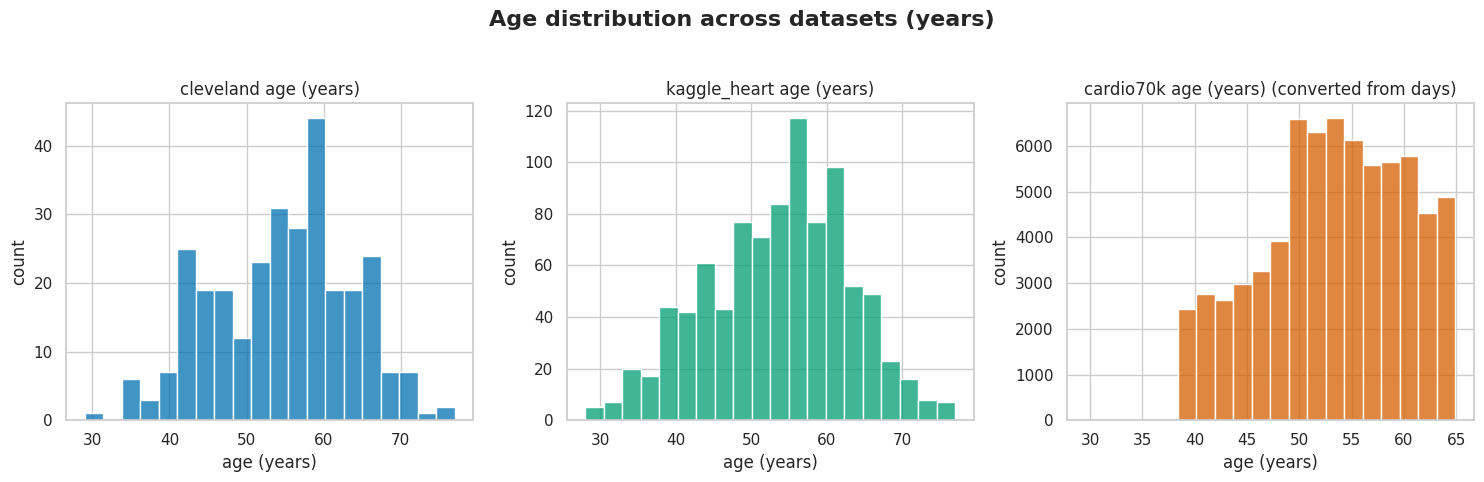

In [9]:
def age_years_getter(name: str, df: pd.DataFrame) -> pd.Series:
    unit = dataset_age_unit(name)
    return age_to_years(df["age_raw"], unit)

age_datasets = {name: raw[name] for name in DATASETS if "age_raw" in raw[name].columns}
fig, axes = plot_numeric_distribution_comparison(
    datasets=age_datasets,
    column="age_raw",
    title="Age distribution across datasets (years)",
    bins=20,
    colors=PALETTE_DATASET,
    value_getter=age_years_getter,
    xlabel="age (years)",
)

for idx, name in enumerate(age_datasets):
    unit = dataset_age_unit(name)
    suffix = " (converted from days)" if unit == "days" else ""
    axes[idx].set_title(f"{name} age (years){suffix}")

### Age groups (raw standardized)
Compare standardized age_group distributions for each dataset.

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'cleveland\n(n=297)'}, ylabel='Count'>,
        <Axes: title={'center': 'kaggle_heart\n(n=918)'}, ylabel='Count'>,
        <Axes: title={'center': 'cardio70k\n(n=70,000)'}, ylabel='Count'>],
       dtype=object))

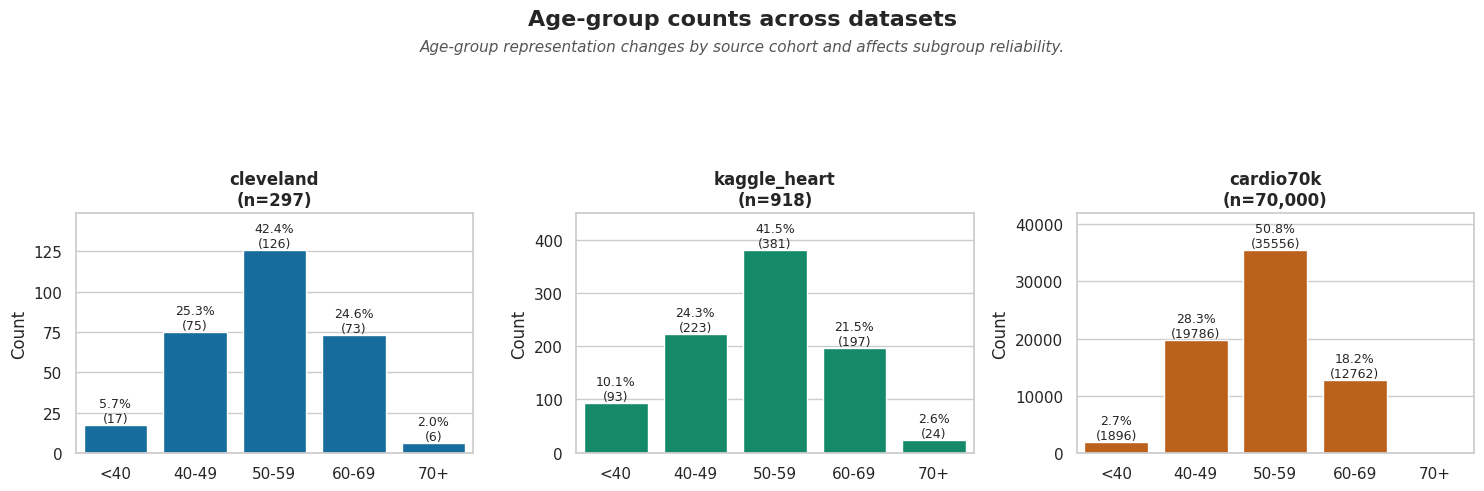

In [10]:
age_group_datasets = {}
combined_age_order = []
for name in DATASETS:
    df = raw[name]
    if "age_group" not in df.columns:
        continue
    order = age_group_order(name)
    for label in order:
        if label not in combined_age_order:
            combined_age_order.append(label)
    age_group_datasets[name] = pd.DataFrame({
        "age_group": apply_age_group_order(df["age_group"], name).astype(str),
    })

plot_categorical_distribution_grid(
    datasets=age_group_datasets,
    column="age_group",
    title="Age-group counts across datasets",
    subtitle="Age-group representation changes by source cohort and affects subgroup reliability.",
    palette=PALETTE_DATASET,
    category_order=combined_age_order,
    show_percentages=True,
    annotate_imbalance=False,
    show=False,
 )

💡 **Why this matters:** Uneven age-group representation can make model behavior look strong overall while hiding weaker performance in underrepresented age bands.

,dataset,age_unit,min,max,mean,median,std
0,cleveland,years,29.000000,77.000000,54.542088,56.000000,9.049736
1,kaggle_heart,years,28.000000,77.000000,53.510893,54.000000,9.432617
2,cardio70k,days,29.563313,64.922656,53.302850,53.943874,6.754967


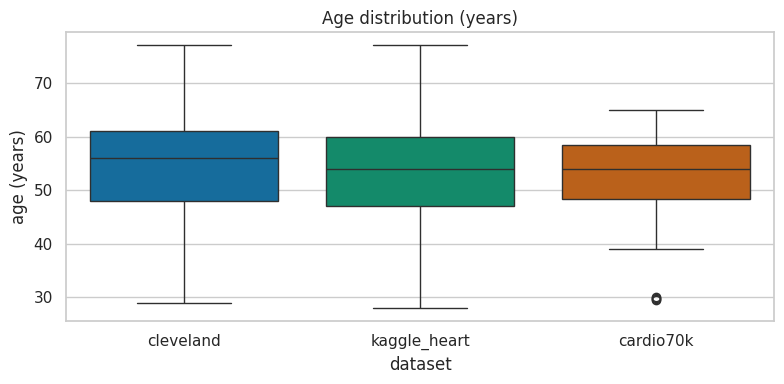

In [11]:
age_stats = []
age_plot_rows = []
for name, df in raw.items():
    unit = dataset_age_unit(name)
    age_years = age_to_years(df["age_raw"], unit)
    age_stats.append({
        "dataset": name,
        "age_unit": unit,
        "min": age_years.min(),
        "max": age_years.max(),
        "mean": age_years.mean(),
        "median": age_years.median(),
        "std": age_years.std(),
    })
    age_plot_rows.append(pd.DataFrame({"dataset": name, "age_years": age_years}))

age_stats_df = pd.DataFrame(age_stats)
age_plot = pd.concat(age_plot_rows, ignore_index=True)
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=age_plot, x="dataset", y="age_years", ax=ax, palette=PALETTE_DATASET)
ax.set_title("Age distribution (years)")
ax.set_xlabel("dataset")
ax.set_ylabel("age (years)")
plt.tight_layout()
display(age_stats_df)

## Sensitive attribute analysis: sex
Compare sex encoding and distribution across datasets.

In [12]:
sex_tables = []
for name, df in raw.items():
    series = resolve_sex_series(df)
    if series is None:
        continue
    counts = series.value_counts(dropna=False)
    total = counts.sum()
    for label, value in counts.items():
        sex_tables.append({
            "dataset": name,
            "sex": label,
            "count": int(value),
            "pct": round(value / total, 4),
        })
sex_df = pd.DataFrame(sex_tables)
display(sex_df)

,dataset,sex,count,pct
0,cleveland,Male,201,0.6768
1,cleveland,Female,96,0.3232
2,kaggle_heart,Male,725,0.7898
3,kaggle_heart,Female,193,0.2102
4,cardio70k,Female,45530,0.6504
5,cardio70k,Male,24470,0.3496


(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'cleveland\n(n=297)'}, ylabel='Count'>,
        <Axes: title={'center': 'kaggle_heart\n(n=918)'}, ylabel='Count'>,
        <Axes: title={'center': 'cardio70k\n(n=70,000)'}, ylabel='Count'>],
       dtype=object))

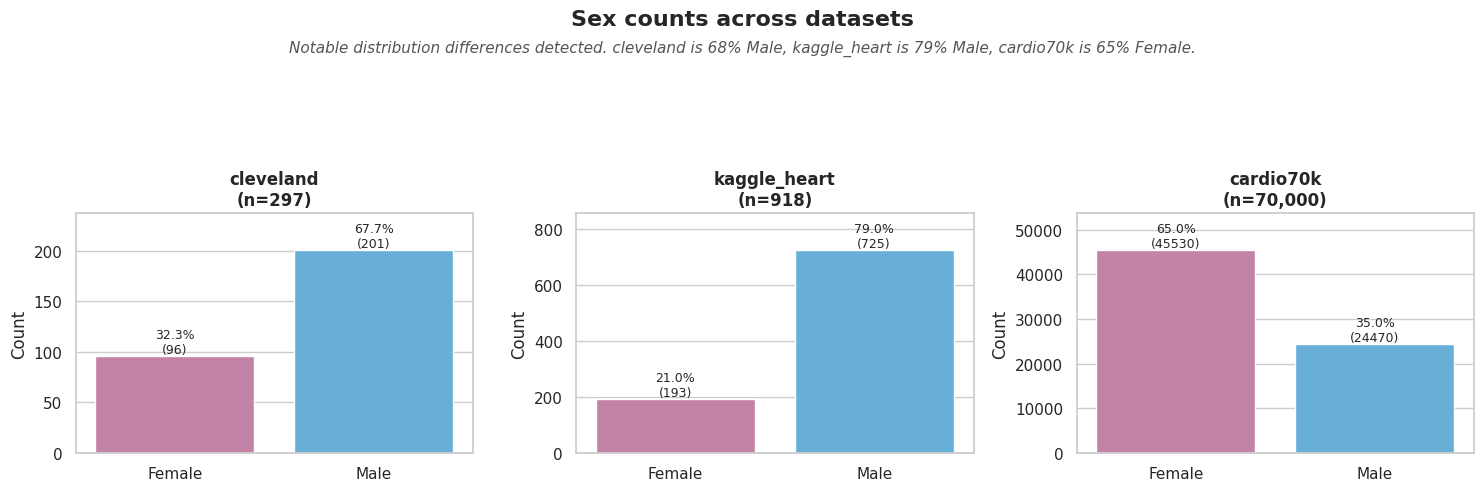

In [13]:
sex_plot_datasets = {}
for name in DATASETS:
    series = resolve_sex_series(raw[name])
    if series is not None:
        sex_plot_datasets[name] = pd.DataFrame({"sex": series.astype(str)})

plot_categorical_distribution_grid(
    datasets=sex_plot_datasets,
    column="sex",
    title="Sex counts across datasets",
    palette=PALETTE_SEX,
    show_percentages=True,
    annotate_imbalance=False,
    show=False,
 )

## Intersectional view: age group x sex
Compare age-group composition by sex within each dataset.

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'cleveland age_group x sex'}, xlabel='age_group', ylabel='count'>,
        <Axes: title={'center': 'kaggle_heart age_group x sex'}, xlabel='age_group', ylabel='count'>,
        <Axes: title={'center': 'cardio70k age_group x sex'}, xlabel='age_group', ylabel='count'>],
       dtype=object))

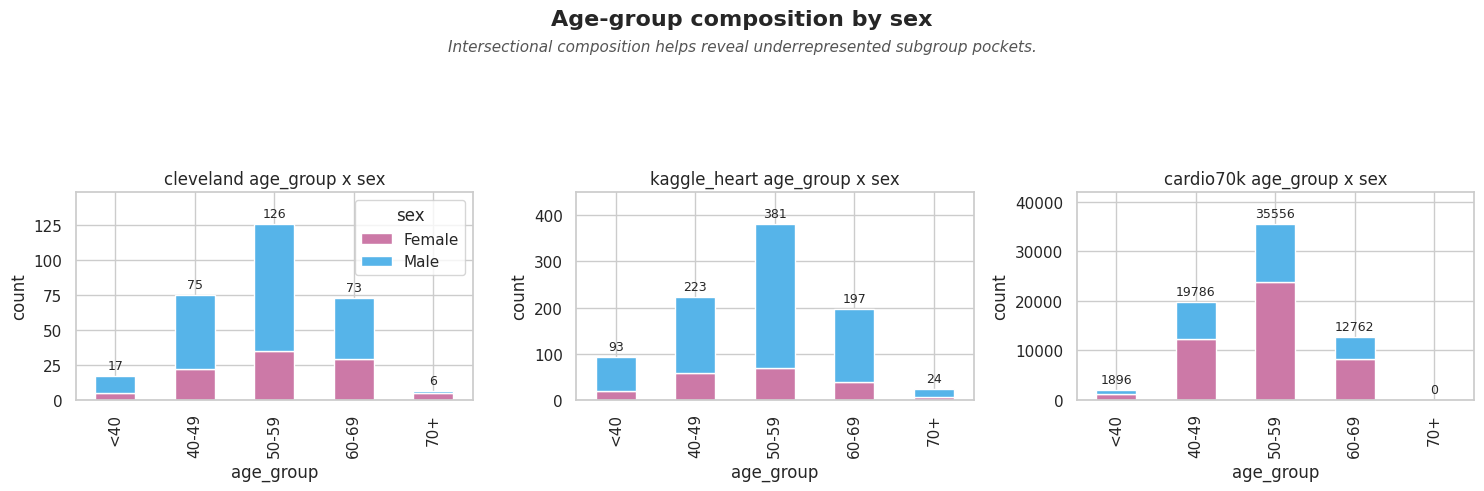

In [29]:
intersectional_datasets = {}
age_order_by_dataset = {}
for name in DATASETS:
    df = raw[name]
    series = resolve_sex_series(df)
    if "age_group" not in df.columns or series is None:
        continue
    intersectional_datasets[name] = pd.DataFrame({
        "age_group": apply_age_group_order(df["age_group"], name).astype(str),
        "sex": series.astype(str),
    })
    age_order_by_dataset[name] = [str(value) for value in age_group_order(name)]

plot_stacked_group_distribution_grid(
    datasets=intersectional_datasets,
    group_col="age_group",
    stack_col="sex",
    title="Age-group composition by sex",
    subtitle="Intersectional composition helps reveal underrepresented subgroup pockets.",
    group_order_by_dataset=age_order_by_dataset,
    stack_order=["Female", "Male"],
    stack_palette=PALETTE_SEX,
    annotate_totals=True,
    show=False,
 )

## Target variable overview
Show heart disease prevalence overall and by sensitive attributes.

In [15]:
target_rows = []
for name, df in raw.items():
    if TARGET_COL in df.columns:
        target_rows.append({"dataset": name, "prevalence": float(df[TARGET_COL].mean())})
pd.DataFrame(target_rows)

,dataset,prevalence
0,cleveland,0.461279
1,kaggle_heart,0.553377
2,cardio70k,0.499700


(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'cleveland heart_disease by sex'}, xlabel='sex', ylabel='prevalence'>,
        <Axes: title={'center': 'kaggle_heart heart_disease by sex'}, xlabel='sex', ylabel='prevalence'>,
        <Axes: title={'center': 'cardio70k heart_disease by sex'}, xlabel='sex', ylabel='prevalence'>],
       dtype=object))

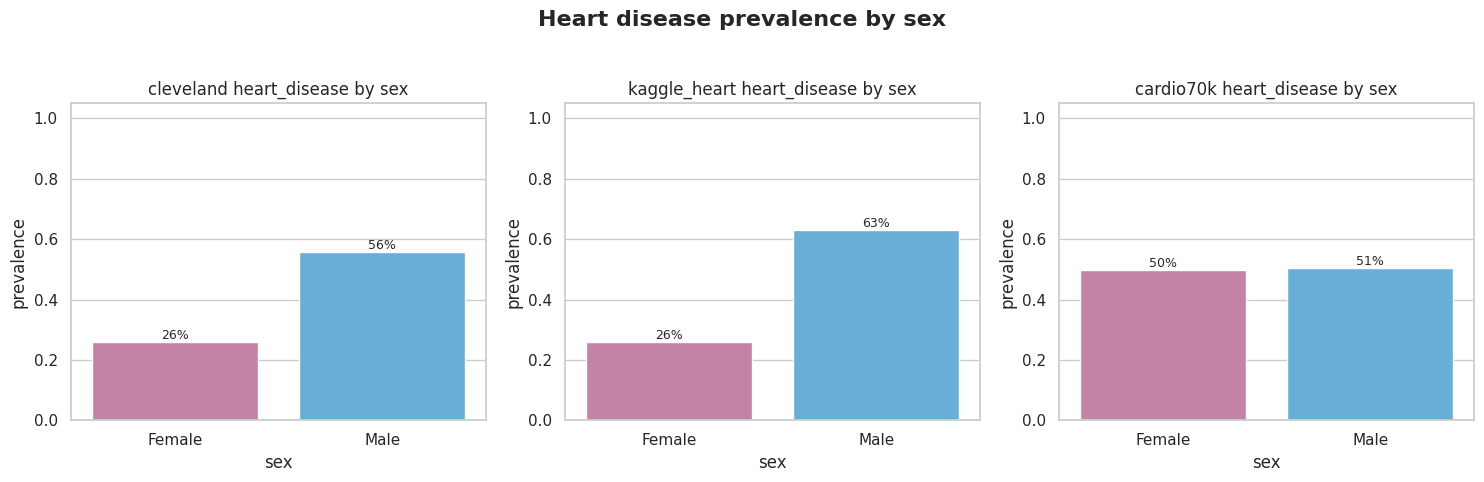

In [16]:
prevalence_by_sex = {}
for name in DATASETS:
    df = raw[name]
    series = resolve_sex_series(df)
    if TARGET_COL in df.columns and series is not None:
        prevalence_by_sex[name] = pd.DataFrame({"sex": series.astype(str), TARGET_COL: df[TARGET_COL]})

plot_target_distribution_by_group(
    datasets=prevalence_by_sex,
    target_col=TARGET_COL,
    group_col="sex",
    title="Heart disease prevalence by sex",
    palette=PALETTE_SEX,
    kind="bar",
    show=False,
 )

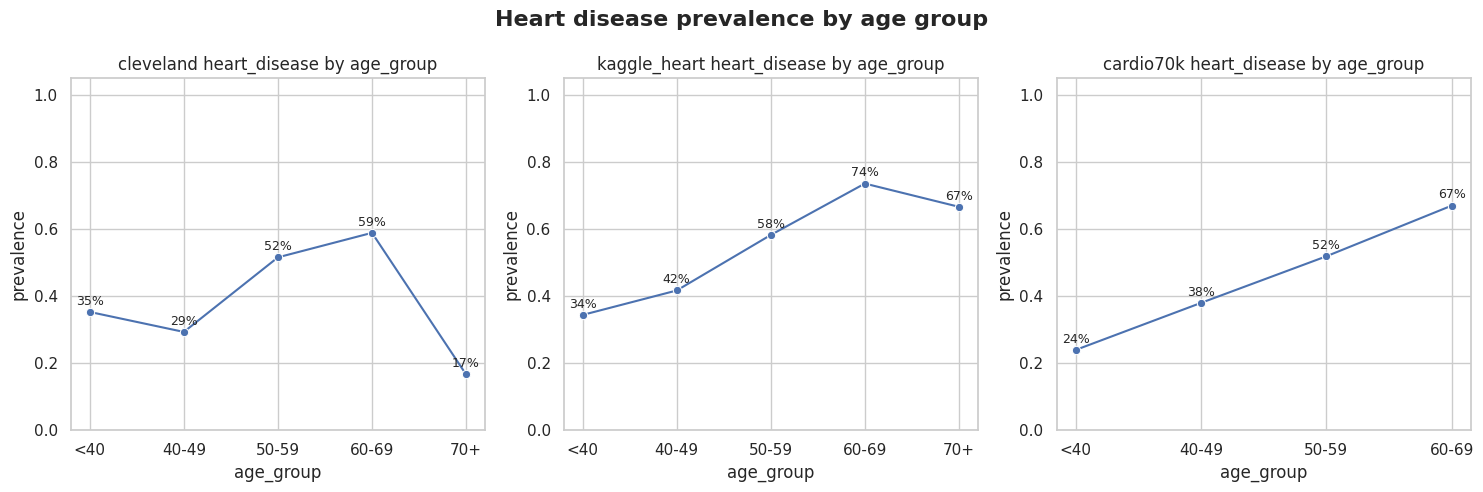

In [17]:
prevalence_by_age_group = {}
for name in DATASETS:
    df = raw[name]
    if TARGET_COL not in df.columns or "age_group" not in df.columns:
        continue
    prevalence_by_age_group[name] = pd.DataFrame({
        "age_group": apply_age_group_order(df["age_group"], name),
        TARGET_COL: df[TARGET_COL],
    })

plot_target_distribution_by_group(
    datasets=prevalence_by_age_group,
    target_col=TARGET_COL,
    group_col="age_group",
    title="Heart disease prevalence by age group",
    kind="line",
    show=False,
 )

plt.tight_layout()

💡 **Why this matters:** Prevalence trends by age group show baseline risk differences that should be separated from true model fairness effects.

## Clinical feature distributions (Cleveland vs Kaggle)
Compare shared clinical features for the two primary datasets.

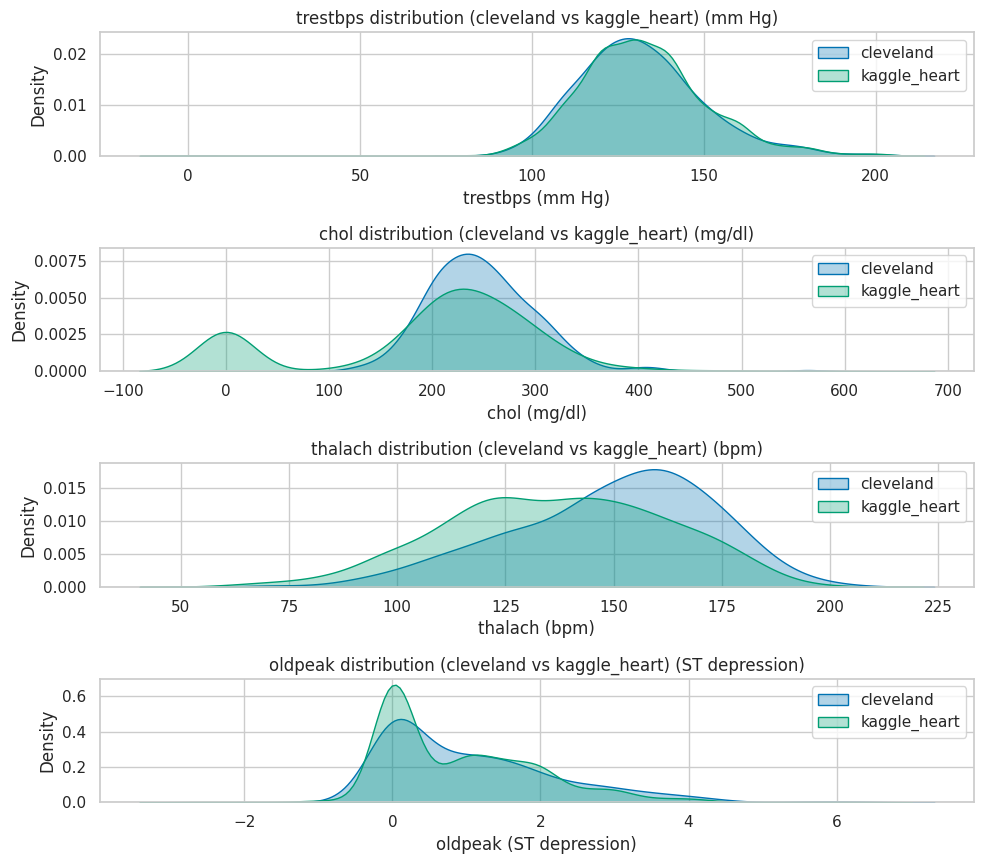

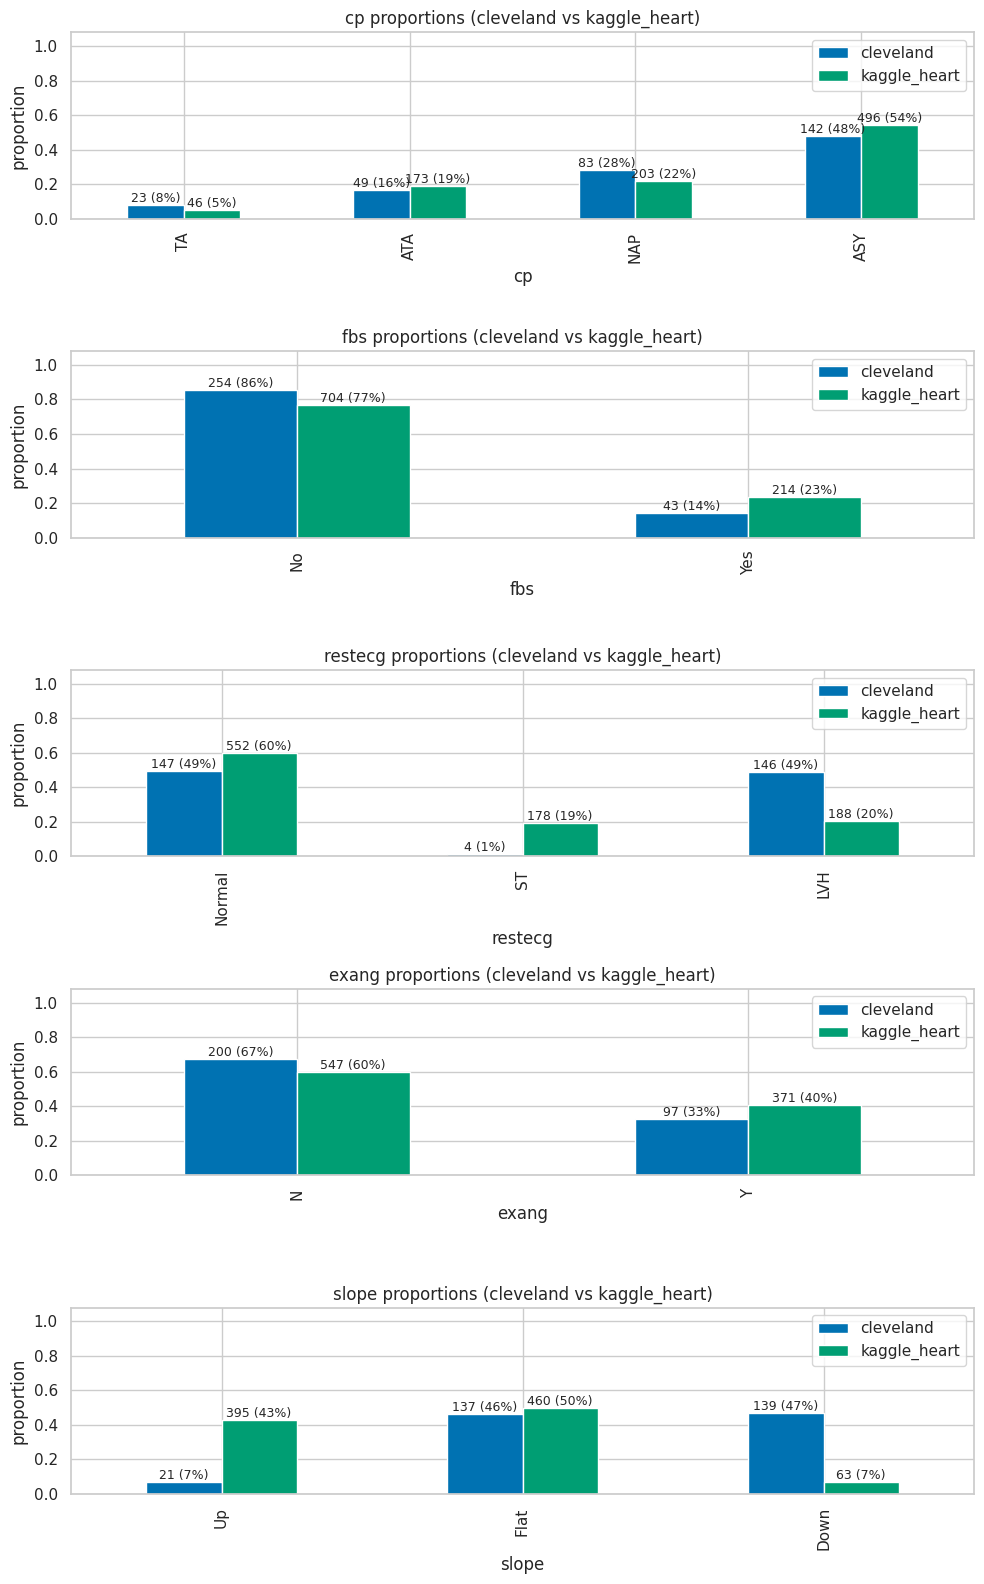

In [42]:
shared_common = [info["canonical"] for info in feature_map.get("common", {}).values()]
cleveland_df = raw["cleveland"]
kaggle_df = raw["kaggle_heart"]

plot_features = [feature for feature in shared_common if feature in cleveland_df.columns and feature in kaggle_df.columns]

distribution_summary = plot_two_dataset_feature_distributions(
    dataset_a=cleveland_df,
    dataset_b=kaggle_df,
    shared_features=plot_features,
    dataset_a_name="cleveland",
    dataset_b_name="kaggle_heart",
    dataset_palette=PALETTE_DATASET,
    units=UNITS,
    categorical_feature_names=set(CARDIAC_CATEGORY_VALUE_LABEL_MAPPING.keys()),
    categorical_series_normalizer=normalize_cardiac_category_series,
    categorical_order_map=CARDIAC_CATEGORY_DISPLAY_ORDER,
    show=False,
 )

numeric_features = distribution_summary["numeric_features"]
categorical_features = distribution_summary["categorical_features"]

In [43]:
print("\nKolmogorov-Smirnov test results (Cleveland vs Kaggle):")
ks_results = summarize_ks_test_between_datasets(
    dataset_a=cleveland_df,
    dataset_b=kaggle_df,
    features=numeric_features,
    dataset_a_name="cleveland",
    dataset_b_name="kaggle_heart",
    alpha=0.05,
    min_unique_values=2,
 )
ks_results


Kolmogorov-Smirnov test results (Cleveland vs Kaggle):


,feature,ks_stat,p_value,n_cleveland,n_kaggle_heart,distributions_differ
0,thalach,0.254704,2.698904e-13,297,918,Yes
1,chol,0.206774,6.938954e-09,297,918,Yes
2,oldpeak,0.091800,4.236559e-02,297,918,Yes
3,trestbps,0.035948,9.219938e-01,297,918,No


## Correlation structure (Cleveland vs Kaggle)
Review correlation patterns for shared clinical features.

(<Figure size 2400x600 with 6 Axes>,
 array([<Axes: title={'center': 'cleveland correlations (n=9)'}>,
        <Axes: title={'center': 'kaggle_heart correlations (n=9)'}>,
        <Axes: title={'center': 'cardio70k correlations (n=12)'}>],
       dtype=object))

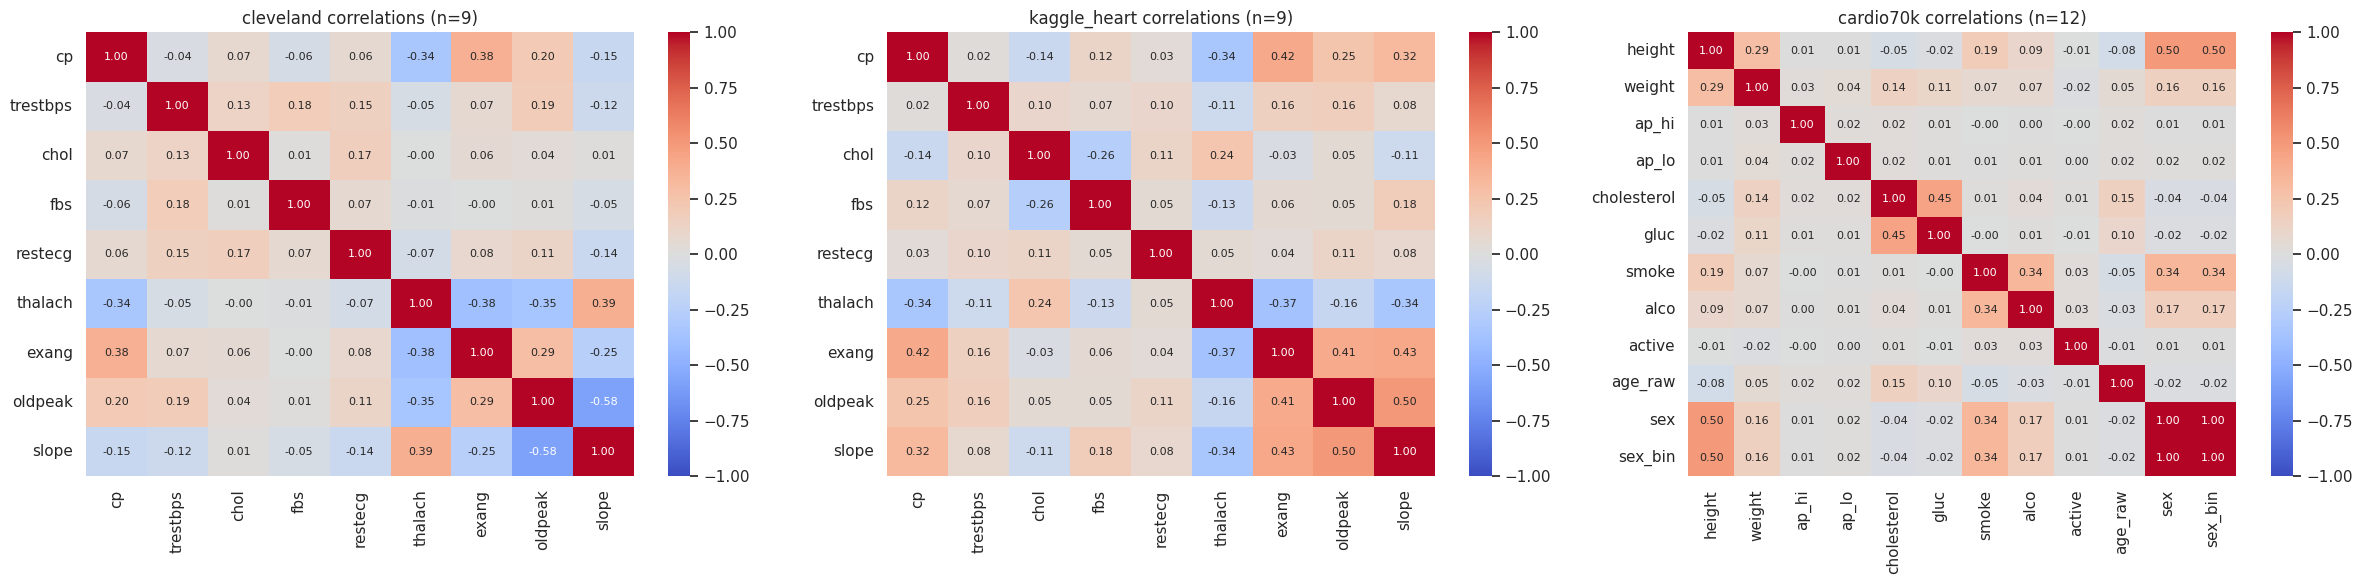

In [34]:
corr_targets = [("cleveland", cleveland_df, plot_features), ("kaggle_heart", kaggle_df, plot_features)]
cardio_df = raw.get("cardio70k")
if cardio_df is not None:
    cardio_features = [c for c in cardio_df.columns if c != TARGET_COL]
    corr_targets.append(("cardio70k", cardio_df, cardio_features))
else:
    corr_targets.append(("cardio70k", pd.DataFrame(), []))

plot_correlation_heatmap_grid(
    corr_targets=corr_targets,
    categorical_feature_names=set(CARDIAC_CATEGORY_VALUE_LABEL_MAPPING.keys()),
    categorical_series_normalizer=normalize_cardiac_category_series,
    figsize=(24, 6),
    annot=True,
    annot_size=8,
    show=False,
 )

## Clustering and similarity view (raw)
Explore potential latent groups beyond age/sex using a simple PCA + KMeans view.

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: title={'center': 'cleveland clustering (PCA)'}, xlabel='PC1', ylabel='PC2'>,
        <Axes: title={'center': 'kaggle_heart clustering (PCA)'}, xlabel='PC1', ylabel='PC2'>,
        <Axes: title={'center': 'cardio70k clustering (PCA)'}, xlabel='PC1', ylabel='PC2'>],
       dtype=object))

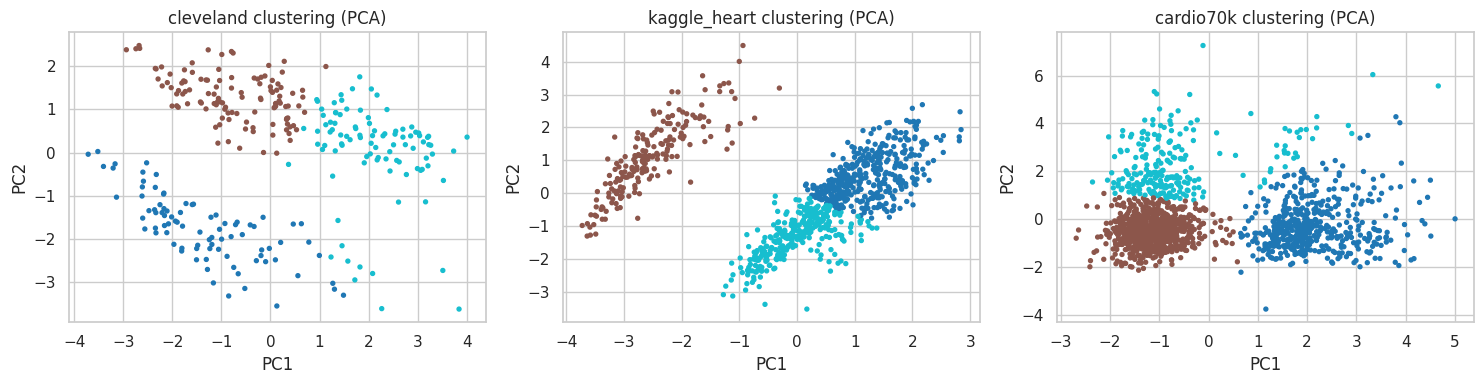

In [35]:
clustering_datasets = {name: raw[name] for name in DATASETS}
plot_pca_kmeans_scatter_grid(
    datasets=clustering_datasets,
    target_col=TARGET_COL,
    n_clusters=3,
    sample_size=1500,
    random_state=42,
    figsize=(15, 4),
    show=False,
 )

## Cardio70k-specific features
Focus on features unique to the 70k dataset and their distributions.

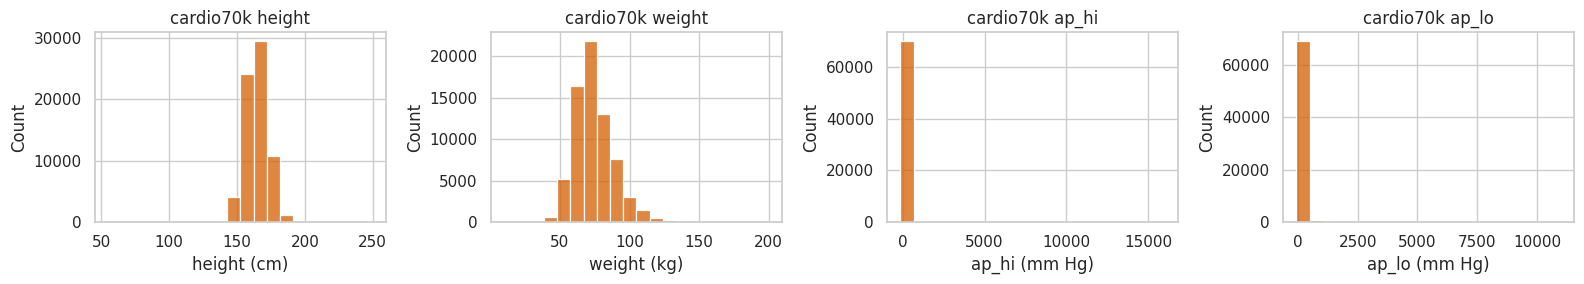

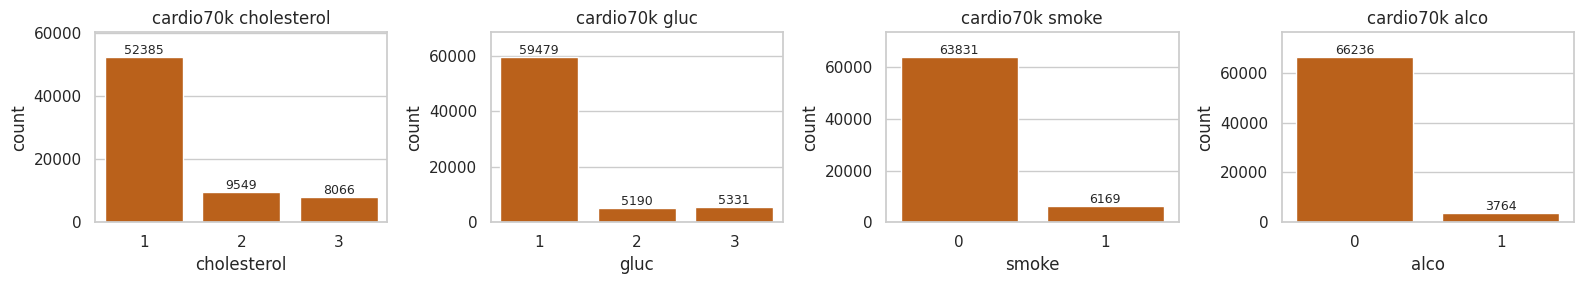

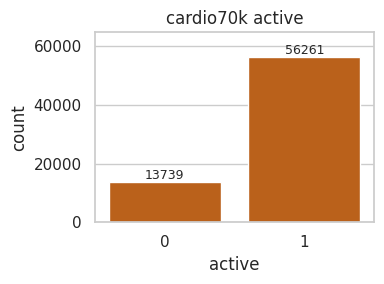

In [37]:
cardio_df = raw.get("cardio70k")
if cardio_df is not None:
    cardio_unique = list(feature_map.get("dataset_specific", {}).get("cardio70k", {}).keys())
    cardio_unique = [feature for feature in cardio_unique if feature in cardio_df.columns]
    if cardio_unique:
        plot_mixed_feature_batches(
            df=cardio_df,
            features=cardio_unique,
            dataset_name="cardio70k",
            color=PALETTE_DATASET["cardio70k"],
            units=UNITS,
            batch_size=4,
            categorical_unique_threshold=5,
            show=False,
        )
    else:
        print("No cardio70k-specific features found in raw data.")

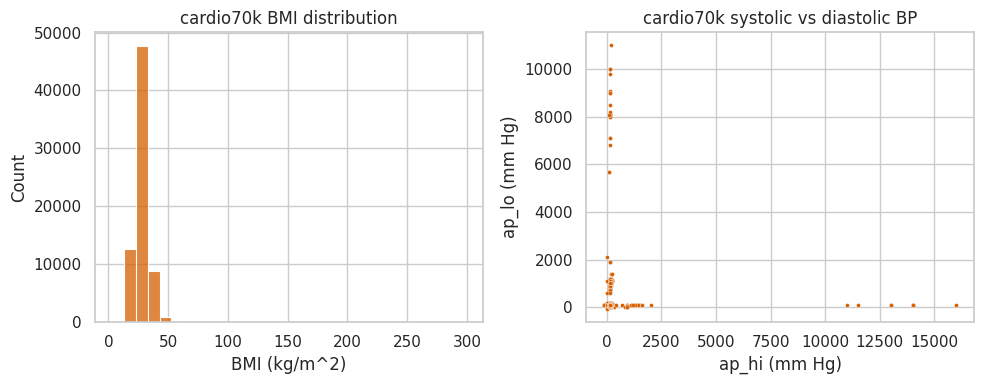

In [38]:
if cardio_df is not None:
    plot_bmi_and_bp_relationship(
        df=cardio_df,
        color=PALETTE_DATASET["cardio70k"],
        height_col="height",
        weight_col="weight",
        systolic_col="ap_hi",
        diastolic_col="ap_lo",
        show=False,
    )

## Baseline and fairness outputs (latest run)
Load baseline and fairness summaries from the most recent run if available.

In [24]:
def resolve_latest_run(results_dir: Path) -> Path | None:
    latest_txt = results_dir / "latest_run.txt"
    if latest_txt.exists():
        run_id = latest_txt.read_text().strip()
        run_dir = results_dir / "runs" / run_id
        if run_dir.exists():
            return run_dir
    return None

latest_run = resolve_latest_run(RESULTS_DIR)
latest_run

PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac/runs/run_20260211_135106_368_17790_cba542')

In [25]:
if latest_run is None:
    print("No latest run found under results/cardiac/runs.")
else:
    baseline_dir = latest_run / "baseline"
    baseline_jsons = list(baseline_dir.glob("**/*baseline_metrics*.json"))
    print(f"Found {len(baseline_jsons)} baseline metric files")
    if baseline_jsons:
        rows = []
        for path in baseline_jsons:
            with open(path, "r") as f:
                data = json.load(f)
            dataset = data.get("dataset") or path.stem
            metrics = data.get("metrics", {})
            rows.append({"dataset": dataset, **metrics})
        display(pd.DataFrame(rows))
    fairness_dir = baseline_dir / "fairness"
    fairness_csvs = list(fairness_dir.glob("*_fairness_summary.csv"))
    if fairness_csvs:
        summaries = []
        for path in fairness_csvs:
            df = pd.read_csv(path)
            df["dataset"] = path.stem.replace("_fairness_summary", "")
            summaries.append(df)
        display(pd.concat(summaries, ignore_index=True))
    print("Note: cardio70k baseline may be missing until baseline training supports it.")

Found 0 baseline metric files


,sensitive_attribute,metric,is_fair,max_difference,tpr_max_difference,fpr_max_difference,split,dataset
0,age_group_cat,demographic_parity,False,0.607843,NaN,NaN,train,cleveland
1,age_group_cat,equalized_odds,False,NaN,1.000000,0.238095,train,cleveland
2,age_group_cat,equal_opportunity,False,1.000000,NaN,NaN,train,cleveland
3,age_group_cat,predictive_parity,False,1.000000,NaN,NaN,train,cleveland
4,sex_cat,demographic_parity,False,0.329870,NaN,NaN,train,cleveland
5,sex_cat,equalized_odds,False,NaN,0.184295,0.081290,train,cleveland
6,sex_cat,equal_opportunity,False,0.184295,NaN,NaN,train,cleveland
7,sex_cat,predictive_parity,False,0.138462,NaN,NaN,train,cleveland
8,age_group_cat,demographic_parity,False,0.590909,NaN,NaN,test,cleveland
9,age_group_cat,equalized_odds,False,NaN,0.833333,0.333333,test,cleveland


Note: cardio70k baseline may be missing until baseline training supports it.


## Key observations
Summary points based on the comparisons above.

- Sex distribution varies across datasets; cardio70k shows a different balance from the clinical cohorts.
- Age ranges are broadly similar in years, but cardio70k requires day-to-year conversion to align with other datasets.
- Several clinical features show distribution shifts between Cleveland and Kaggle, confirmed by KS-test results for numeric features.
- Cardio70k introduces lifestyle and exam variables (e.g., activity, alcohol, blood pressure) not present in the clinical datasets.